In [1]:
# Importar todas las librerias necesarias
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
# Leer el archivo csv
df = pd.read_csv("US_Top_50_Universities_2026.csv")

In [10]:
# Exploramos los datos
print(df.isnull().sum())
print(df.describe())

University_Name          0
National_Rank            0
Founded_Year             0
Institution_Type         0
State                    0
Research_Impact_Score    0
Intl_Student_Ratio       0
Employment_Rate          0
dtype: int64
       National_Rank  Founded_Year  Research_Impact_Score  Intl_Student_Ratio  \
count       50.00000      50.00000              50.000000           50.000000   
mean        25.50000    1844.04000              80.662000           44.630000   
std         14.57738      64.89142              23.380856           31.729985   
min          1.00000    1636.00000              28.500000            4.200000   
25%         13.25000    1817.50000              82.100000           14.900000   
50%         25.50000    1858.50000              89.650000           35.800000   
75%         37.75000    1884.50000              96.250000           73.950000   
max         50.00000    1965.00000             100.000000           94.200000   

       Employment_Rate  
count        50.

In [12]:
# Vamos a visualizar los porcentajes de empleo segun la universidad
# Tenemos que ordenar el dataframe segun Employmet_Rate

df_sorted = df.sort_values("Employment_Rate",ascending=False).head(20)
df_sorted

,University_Name,National_Rank,Founded_Year,Institution_Type,State,Research_Impact_Score,Intl_Student_Ratio,Employment_Rate
3,Stanford University,4,1891,Private,CA,99.5,73.5,97.8
0,Massachusetts Institute of Technology (MIT),1,1861,Private,MA,100.0,91.6,96.2
23,California Institute of Technology (Caltech),24,1891,Private,CA,96.8,90.7,95.1
5,Harvard University,6,1636,Private,MA,98.9,81.4,95.0
9,University of Pennsylvania,10,1740,Private,PA,96.1,76.3,94.8
2,Princeton University,3,1746,Private,NJ,99.0,70.0,94.5
31,Georgia Institute of Technology (Georgia Tech),32,1885,Public,GA,90.4,81.5,94.2
42,Carnegie Mellon University,43,1900,Private,PA,99.0,84.3,93.7
8,Yale University,9,1701,Private,CT,97.2,72.7,93.3
25,Claremont McKenna College,26,1946,Private,CA,35.2,15.6,93.1


C:\Users\Dario\AppData\Local\Temp\ipykernel_16692\123318388.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  plot = sns.barplot(


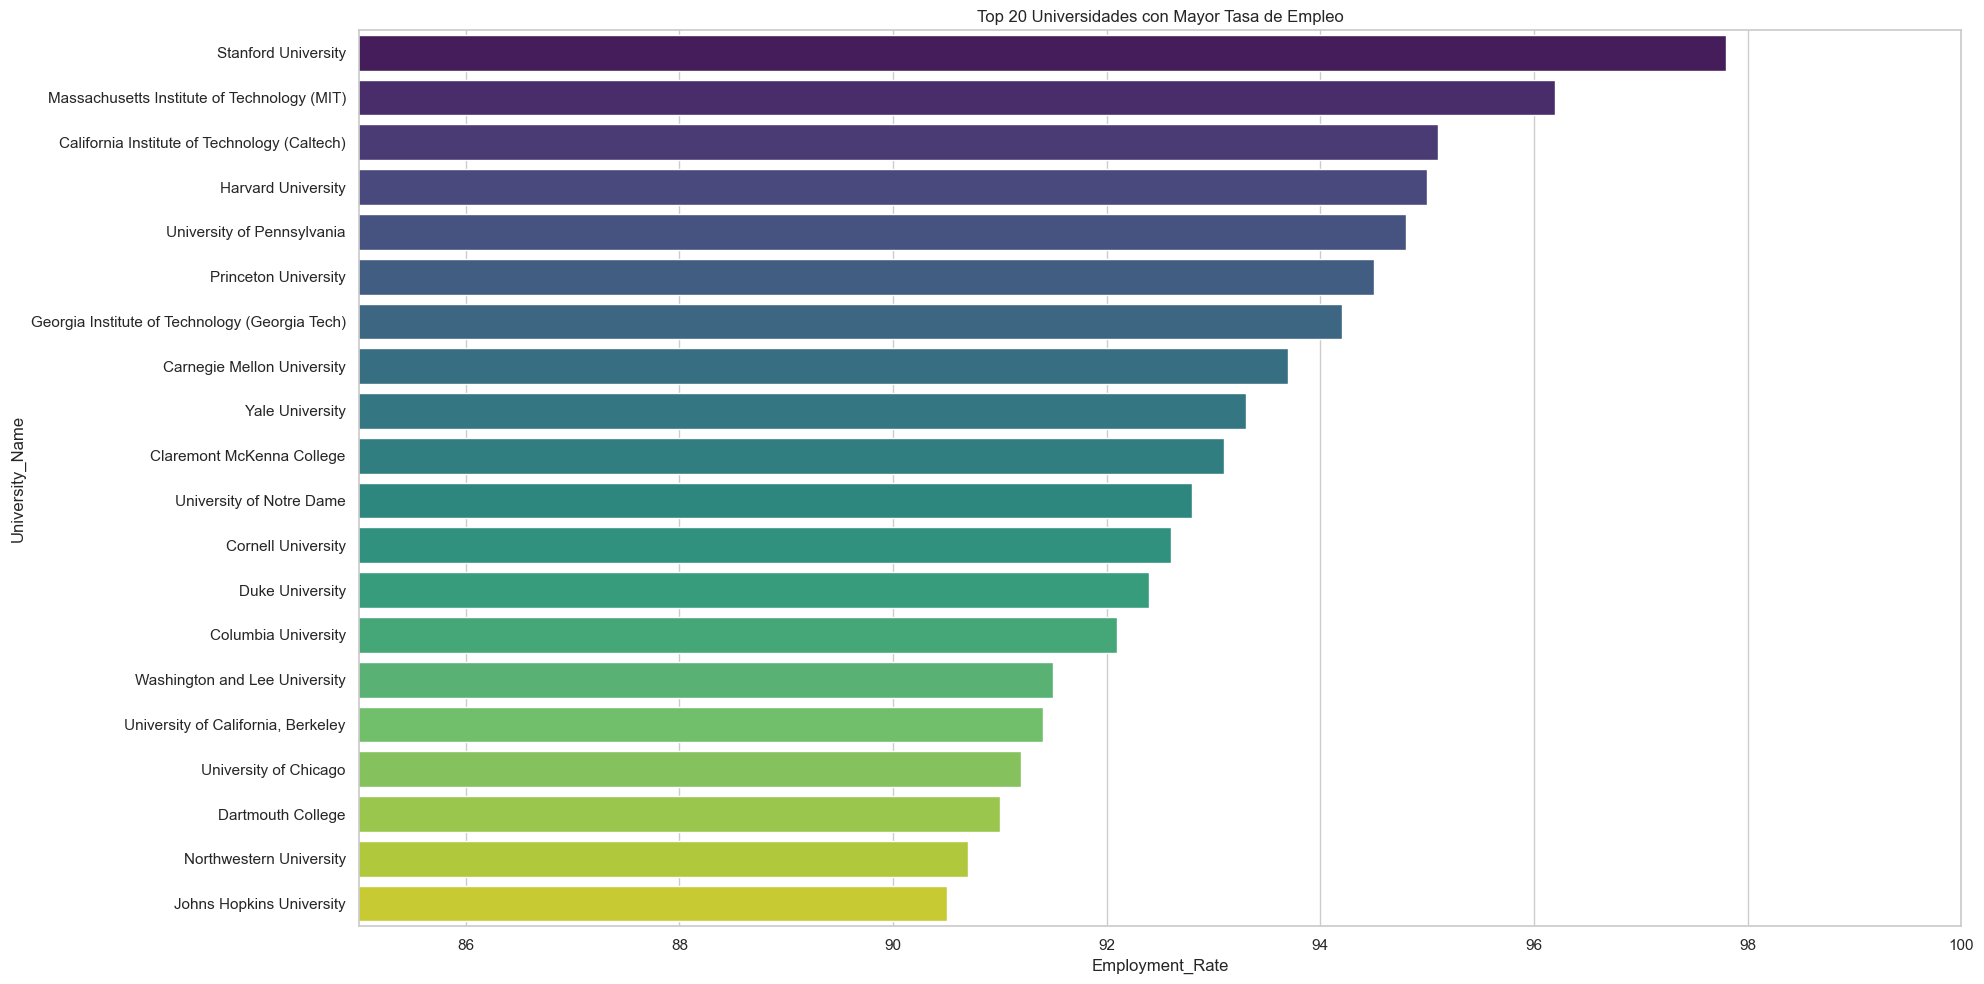

In [16]:
# Configurar el estilo visual
plt.figure(figsize=(20,10))
sns.set_theme(style="whitegrid")

# Crear el grafico
plot = sns.barplot(
    data=df_sorted,
    x="Employment_Rate",
    y="University_Name",
    palette="viridis",
    legend=False
)

plot.set_title("Top 20 Universidades con Mayor Tasa de Empleo")
plt.xlim(85,100)
plt.tight_layout()
plt.show()

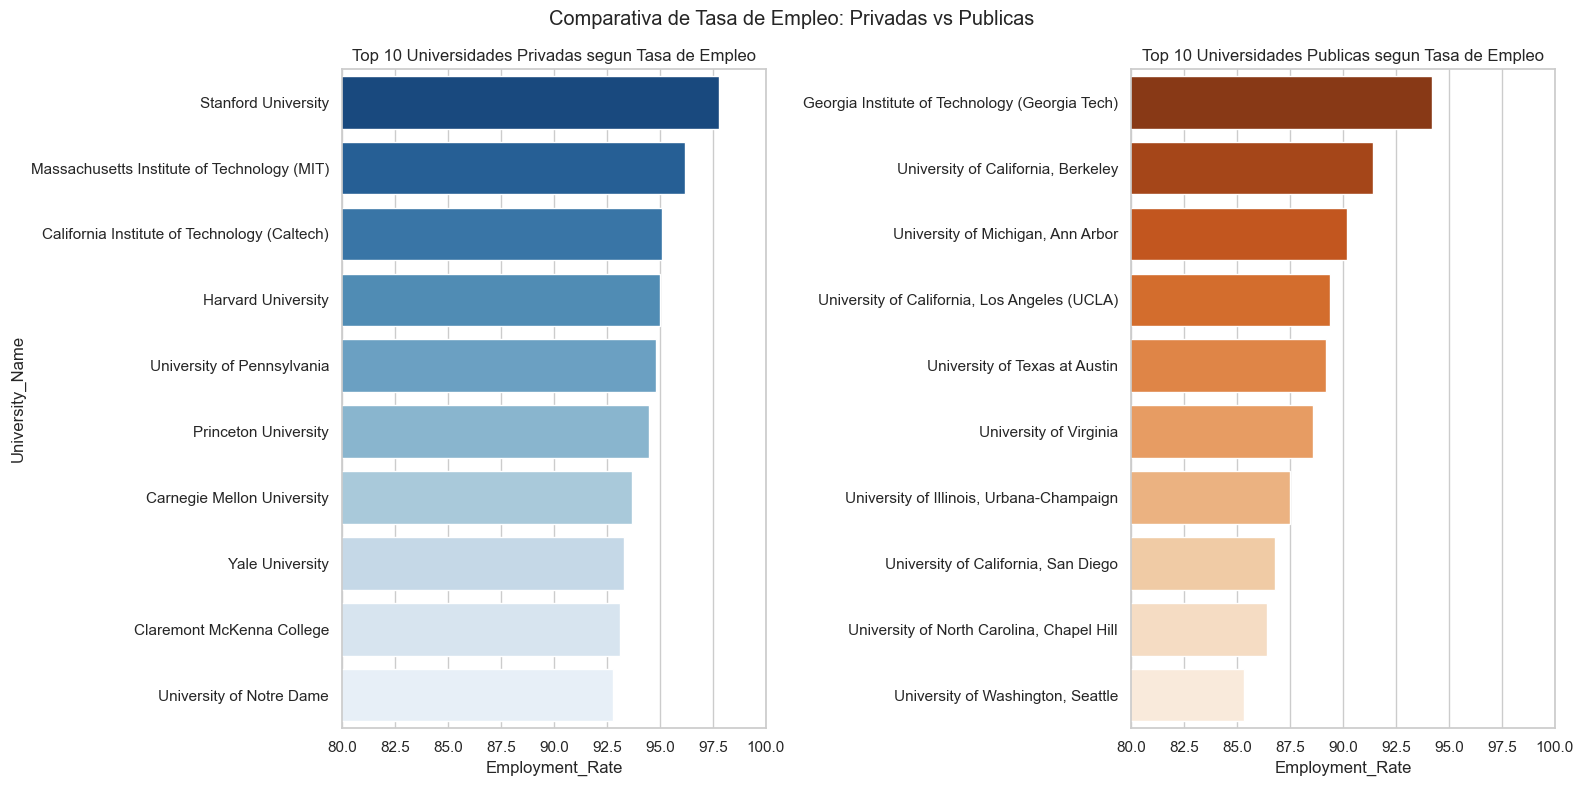

In [19]:
df_privados = df[df["Institution_Type"]=="Private"].sort_values("Employment_Rate",ascending=False).head(10)
df_publicos = df[df["Institution_Type"]=='Public'].sort_values("Employment_Rate",ascending= False).head(10)

fig,axes = plt.subplots(1,2,figsize=(16,8),sharex=True)

# Primer grafico
sns.barplot(
    data=df_privados,
    x="Employment_Rate",
    y="University_Name",
    palette="Blues_r",
    hue="University_Name",
    ax=axes[0],
    legend=False
)
axes[0].set_title("Top 10 Universidades Privadas segun Tasa de Empleo")
axes[0].set_xlim(80,100)

# Segundo grafico
sns.barplot(
    data=df_publicos,
    x="Employment_Rate",
    y="University_Name",
    palette="Oranges_r",
    hue="University_Name",
    ax=axes[1],
    legend=False
)
axes[1].set_title("Top 10 Universidades Publicas segun Tasa de Empleo")
axes[1].set_xlim(80,100)
axes[1].set_ylabel("")

plt.suptitle("Comparativa de Tasa de Empleo: Privadas vs Publicas")
plt.tight_layout()
plt.show()

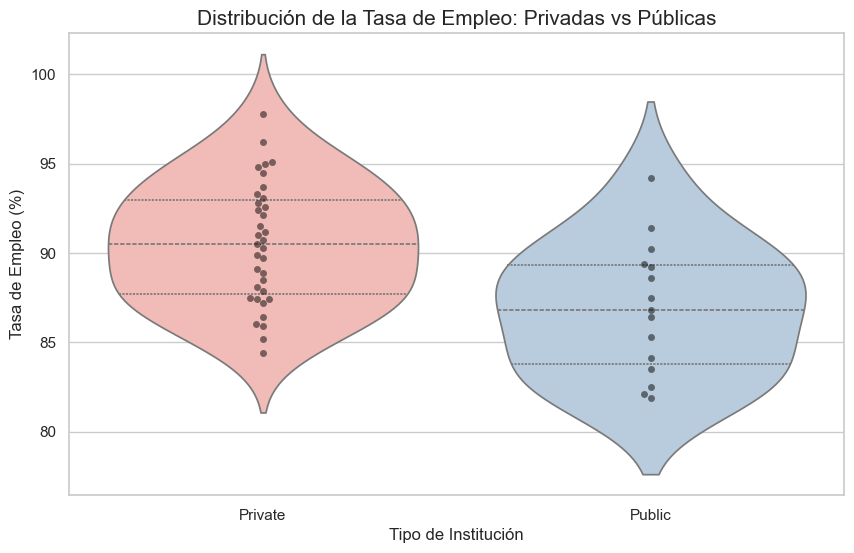

In [20]:
plt.figure(figsize=(10, 6))
sns.set_theme(style="whitegrid")

# 3. Crear el gráfico de violín
# X es la categoría, Y es el valor numérico
sns.violinplot(
    data=df, 
    x="Institution_Type", 
    y="Employment_Rate", 
    palette="Pastel1",
    inner="quartile", # Dibuja líneas para la mediana y los cuartiles dentro del violín
    hue="Institution_Type",
    legend=False
)

# 4. Añadir un "Swarmplot" encima (opcional pero recomendado)
# Esto dibuja cada universidad como un puntito para ver los datos reales
sns.swarmplot(data=df, x="Institution_Type", y="Employment_Rate", color="black", alpha=0.5)

# 5. Títulos
plt.title("Distribución de la Tasa de Empleo: Privadas vs Públicas", fontsize=15)
plt.xlabel("Tipo de Institución", fontsize=12)
plt.ylabel("Tasa de Empleo (%)", fontsize=12)

plt.show()

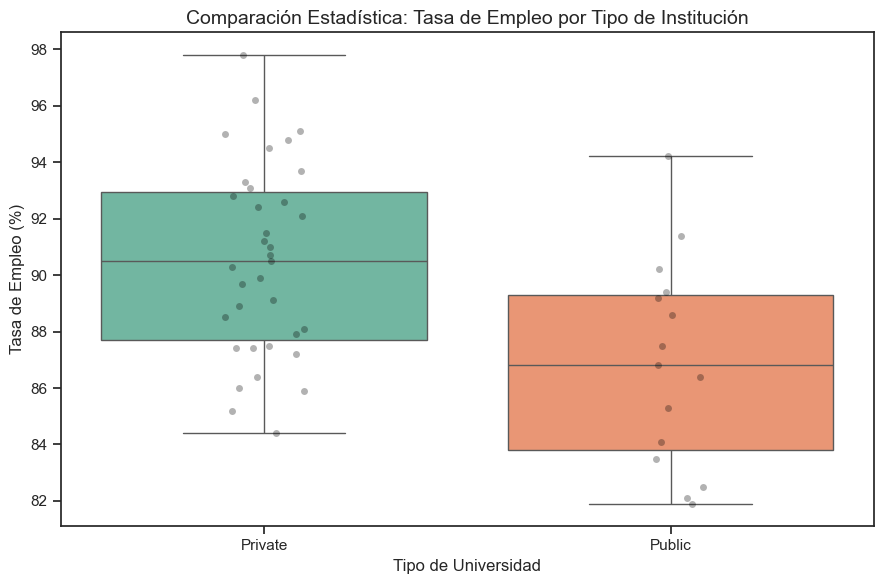

In [23]:
# Creamos un Boxplot para mejor visualizacion de privads vs publicas
plt.figure(figsize=(9,6))
sns.set_theme(style="ticks")

sns.boxplot(
    data=df,
    x="Institution_Type",
    y="Employment_Rate",
    palette="Set2",
    hue="Institution_Type",
    legend=False
)

plt.title("Comparación Estadística: Tasa de Empleo por Tipo de Institución", fontsize=14)
plt.xlabel("Tipo de Universidad", fontsize=12)
plt.ylabel("Tasa de Empleo (%)", fontsize=12)

sns.stripplot(data=df, x="Institution_Type", y="Employment_Rate",color="black",alpha=0.3)
plt.tight_layout()
plt.show()

In [ ]:
# Vemos que efectivamente existe una diferencia entre la cantidad de 
# personas que obtienen un trabajo segun el tipo de universidad. 
# Las privadas tienen una tasa de empleo mas alta que las publicas. 
# Sin embargo, tambien es importante destacar que existen universidades 
# publicas con tasas de empleo muy altas, lo que indica que no todas las 
# universidades publicas tienen una tasa de empleo baja.